## 제품 유형 1에 대한 머신러닝 모델

In [16]:
# ============================================================
# 라이브러리 Import
# ============================================================

# 기본
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import display
import warnings
import platform

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 모델 학습 및 평가 지표
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score, # PR-AUC 수치 계산
    PrecisionRecallDisplay # PR Curve 시각화
)

# XGBoost / LightGBM
import xgboost as xgb
from xgboost import XGBClassifier

import lightgbm as lgb
from lightgbm import LGBMClassifier

# SHAP
import shap


# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# matplotlib 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 고정
np.random.seed(42)

print("=" * 60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("=" * 60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


---
---
### 1. 데이터 로드

In [17]:
# 1. 전체 데이터 호출
df_original_1 = pd.read_csv('../data/ML_modeling_data_product-1.csv')

# 2. 타겟(y) 컬럼과 제외할 컬럼 정의
target_cols = "is_defect"
drop_cols = [
    target_cols,
    "coolant_pressure",
    "spray_1_time",
    "velocity_1",
    "velocity_3",
    "shot_key"
]

# 3. 피쳐(X)와 타겟(y) 분리
X = df_original_1.drop(columns=drop_cols)
y = df_original_1[target_cols]

print("=" * 30)
print(f"피쳐(X)의 크기 : {X.shape}")   # (4207, 16) 나오면 정상
print(f"타겟(y)의 크기 : {y.shape}")   # (4207,)    나오면 정상
print("=" * 30)

피쳐(X)의 크기 : (4207, 16)
타겟(y)의 크기 : (4207,)


### 2. Train/Test 데이터 분리 및 저장
- Train : Test = 8 : 2
- 프로젝트 진행 중, 코드를 실행하는 환경에 따라 모델의 성능이 다르게 평가되는 것을
방지하기 위하여 각각의 데이터를 csv 형식으로 저장함

In [18]:
# 1. Train/Test 데이터 분리 (80:20)
X_train_p1, X_test_p1, y_train_p1, y_test_p1 = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y, # 불량 비율 유지
    shuffle=True # 분리하기 전 데이터 섞기
)

print("=" * 30)
print(f"Train 샘플 수(X) : {len(X_train_p1):,}개")
print(f"Train 샘플 수(y) : {len(y_train_p1):,}개")
print('-' * 30)
print(f"Test  샘플 수(X) : {len(X_test_p1):,}개")
print(f"Test  샘플 수(y) : {len(y_test_p1):,}개")
print('-' * 30)
print(f"Train 불량률  : {y_train_p1.mean() * 100:.2f}%")
print(f"Test  불량률  : {y_test_p1.mean() * 100:.2f}%")
print("=" * 30)

Train 샘플 수(X) : 3,365개
Train 샘플 수(y) : 3,365개
------------------------------
Test  샘플 수(X) : 842개
Test  샘플 수(y) : 842개
------------------------------
Train 불량률  : 17.56%
Test  불량률  : 17.58%


In [19]:
# 2. csv 형식으로 Train/Test 데이터 저장
df_train_p1 = pd.concat([X_train_p1, y_train_p1], axis=1) # aixs=1 : 컬럼을 기준으로 병합
df_test_p1  = pd.concat([X_test_p1,  y_test_p1],  axis=1)

df_train_p1.to_csv('../data/train_data_product-1.csv', index=False)
df_test_p1.to_csv('../data/test_data_product-1.csv',   index=False)

print("Train Data 저장 완료")
print("Test Data 저장 완료")

Train Data 저장 완료
Test Data 저장 완료


### 3. 모델링

#### 3.1 클래스 불균형 문제를 해결하기 위한 가중치 계산
- 소수 클래스인 불량(1)에 가중치를 부여하는 파라미터를 지원하는 XGBoost 모델을 위해 계산함

In [21]:
# 1. 소수 클래스인 불량에 부여할 가중치 계산 (XGBoost)

cnt_of_normal = (y_train_p1 == 0).sum() # 정상 제품(0)의 개수
cnt_of_defect = (y_train_p1 == 1).sum() # 불량 제품(1)의 개수
weights = cnt_of_normal / cnt_of_defect

print("=" * 30)
print(f"정상 샘플 수: {cnt_of_normal:,}개")
print(f"불량 샘플 수: {cnt_of_defect:,}개")
print(f"scale_pos_weight: {weights:.4f}")
print("=" * 30)

정상 샘플 수: 2,774개
불량 샘플 수: 591개
scale_pos_weight: 4.6937


#### 3.2 XGBoost - 기초
- 학습율 0.1를 제외하고, XGBoost의 기본 파라미터를 사용해 baseline 확인

In [23]:
# 1. default 파라미터로 빠르게 학습해서 GridSearch 전 기준점(Baseline) 성능을 확인
xgb_base_p1 = XGBClassifier(
    learning_rate=0.1,
    scale_pos_weight=weights,  # 불균형 보정 (정상/불량 = 4.6937)
    eval_metric="logloss",     # 내부 평가 기준 (이진 분류 표준)
    random_state=42,           # 재현성 보장
    n_jobs=-1                  # 모든 CPU 코어 사용
)
# 기본 파라미터 사용
    # n_estimators = 100
    # max_depth = 6
    # subsample = 1.0
    

# 2. Train 데이터로 학습
xgb_base_p1.fit(X_train_p1, y_train_p1)

print("=" * 30)
print("XGBoost Base 학습 완료!")
print("=" * 30)

XGBoost Base 학습 완료!


#### 3.3 LightGBM - 기초
- 학습율 0.1를 제외하고, LightGBM의 기본 파라미터를 사용해 baseline 확인 

In [24]:
# 1. default 파라미터로 빠르게 학습해서 GridSearch 전 기준점(Baseline) 성능을 확인
lgbm_base_p1 = LGBMClassifier(
    learning_rate=0.1,
    class_weight={0: 1, 1: weights}, # 불균형 보정 (정상/불량 = 4.6937)
    # 정상(0)에는 가중치 1, 불량(1)에는 위에서 계산한 가중치 적용
    random_state=42, # 재현성 보장
    n_jobs=-1, # 모든 CPU 코어 사용
    verbose=-1 # LightGBM 자체적으로 학습과정을 출력하는 것을 억제
)
# 기본 파라미터 사용
    # n_estimators = 100
    # max_depth = -1 (제한 없음)
    # subsample = 1.0

# 2. Train 데이터로 학습
lgbm_base_p1.fit(X_train_p1, y_train_p1)

print("=" * 30)
print("LightGBM Base 학습 완료!")
print("=" * 30)

LightGBM Base 학습 완료!


#### 3.4 모델의 성능 평가 함수 정의
- 목적 : 기초 / 성능 최적화 모델에 모두 적용할 수 있는 평가 함수 제작
- 평가지표: 혼동행렬 / Classification Report / PR-AUC
- 함수 인자 설명
    - model: 평가할 모델
    - X_test: 테스트 피쳐
    - y_test: 테스트 타겟
    - graph_title: 그래프 제목에 표시할 이름

In [ ]:
def evaluate_model(model, X_test, y_test, graph_title):
    
    # 1. 예측
    y_pred = model.predict(X_test) # 클래스 예측 (0 또는 1) - 확률이 0.5 이상일 때 불량으로 예측
    y_prob = model.predict_proba(X_test)[:, 1] # 불량(1)일 확률

    # 2. PR-AUC(곡선 아래 면적) 계산
    pr_auc   = average_precision_score(y_test, y_prob) # PR-AUC 곡선 아래 면적 계산
    baseline = y_test.mean() # 테스트 데이터의 불량률 -> PR-AUC 곡선의 기준선

    # 3. Precision / Recall / F1-Score 출력
    print(f"\n{'=' * 55}")
    print(f"  {graph_title}")
    print(f"{'=' * 55}")
    print(f"\nPR-AUC: {pr_auc:.4f}   (Random Baseline: {baseline:.4f})")
    print(f"\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["정상(0)", "불량(1)"]))

    # 4. 시각화
    # fig는 안 쓸거라서 _로 처리
    # facecolor='none'의 의미: 배경을 투명하게 
    _, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='none') 

    # 5. 혼동행렬
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
        xticklabels=["정상(0)", "불량(1)"],
        yticklabels=["정상(0)", "불량(1)"],
        annot_kws={"size": 16}
    )
    # 5-1. 각 셀에 TN / FP / FN(위험) / TP 표시
    cell_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            axes[0].text(j + 0.5, i + 0.78, cell_labels[i][j],
                        ha="center", va="center",
                        color="gray", fontsize=9)
    axes[0].set_title(f"{graph_title}\nConfusion Matrix", fontsize=13)
    axes[0].set_ylabel("실제값", fontsize=11)
    axes[0].set_xlabel("예측값", fontsize=11)

    # 6. PR Curve
    disp = PrecisionRecallDisplay.from_predictions(
    y_test, y_prob,
    name=f"{graph_title} (PR-AUC = {pr_auc:.4f})",
    ax=axes[1],
    color="steelblue"
    )
    # 자동으로 표시되는 Average Precision(AP)를 덮어씌워서 숨김
    disp.line_.set_label(f"{graph_title} (PR-AUC = {pr_auc:.4f})")

    # 6-1. PR Curve 기준선 
    axes[1].axhline(
        y=baseline, color="gray", linestyle="--", linewidth=1.2,
        label=f"Random Baseline ({baseline:.4f})"
    )
    axes[1].set_title(f"{graph_title}\nPR Curve", fontsize=13)
    axes[1].legend(
    fontsize=10,
    bbox_to_anchor=(0.5, -0.15),  # 그래프 아래쪽으로 범례 이동
    loc='upper center',            # 기준점 설정
    ncol=1                         # 범례 1열로 표시
    )

    plt.tight_layout()
    plt.show()

#### 3.5 기초 모델의 성능 평가
- 학습율(=0.1)을 제외하고 기본 파라미터를 활용해 제작한 기초 모델의 성능 확인


  XGBoost 기초 모델링 - Product 1

PR-AUC: 0.5596   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.95      0.80      0.87       694
       불량(1)       0.46      0.79      0.58       148

    accuracy                           0.80       842
   macro avg       0.70      0.80      0.73       842
weighted avg       0.86      0.80      0.82       842



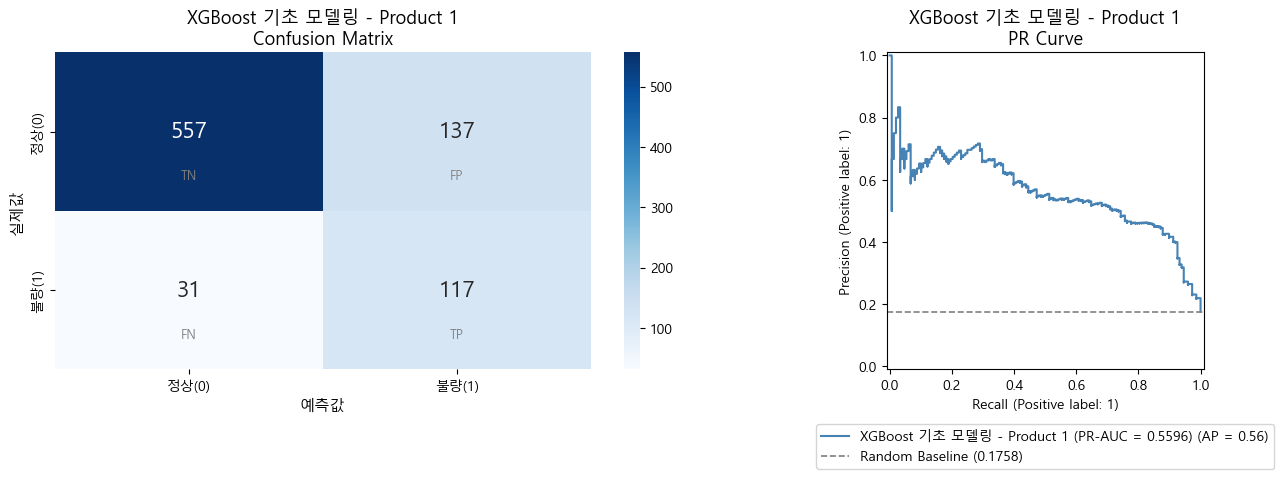

In [28]:
# 1. XGBoost 기초모델링의 성능 평가
evaluate_model(xgb_base_p1,  X_test_p1, y_test_p1, "XGBoost 기초 모델링 - Product 1")


  LightGBM 기초 모델링 - Product 1

PR-AUC: 0.6054   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.95      0.85      0.90       694
       불량(1)       0.53      0.80      0.63       148

    accuracy                           0.84       842
   macro avg       0.74      0.82      0.77       842
weighted avg       0.88      0.84      0.85       842



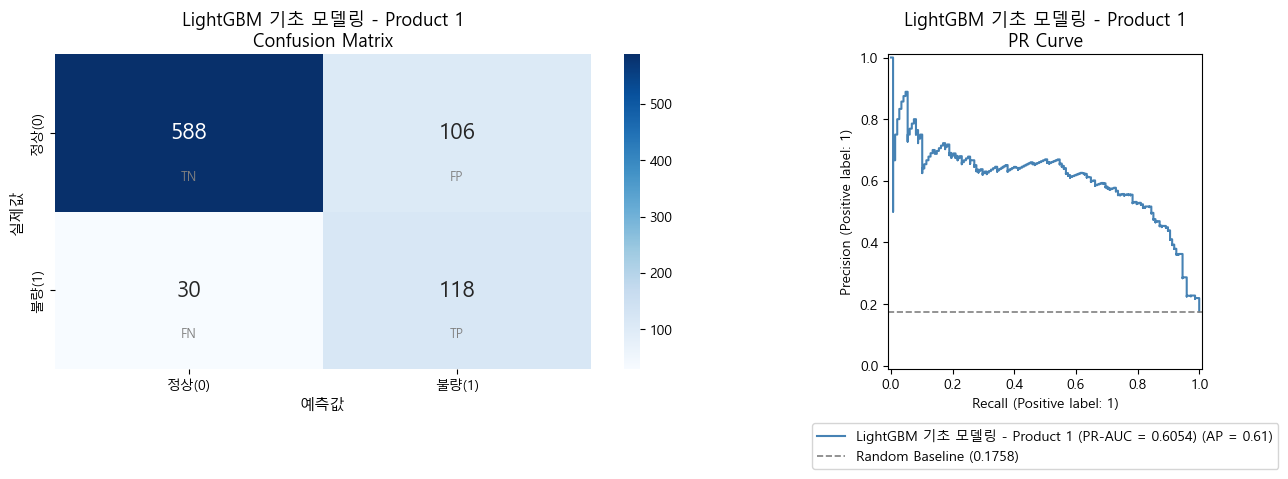

In [29]:
# 2. LightGBM 기초모델링의 성능 평가
evaluate_model(lgbm_base_p1, X_test_p1, y_test_p1, "LightGBM 기초 모델링 - Product 1")

#### 3.6 XGBoost의 GridSearch
- 목표:머신러닝 모델의 파라미터 중 최적의 파라미터를 찾아 성능 개선

In [ ]:
# 1. 탐색할 파라미터 후보 정의
xgb_params = {
    "n_estimators"    : [100, 300, 500], # 트리 개수
    "max_depth"       : [3, 5, 7], # 트리 깊이
    "learning_rate"   : [0.05, 0.1], # 학습률
    "subsample"       : [0.8, 1.0], # 트리 학습 시 전체 샘플 중 몇 %를 사용할 것인가?
    "colsample_bytree": [0.8, 1.0], # 트리 학습 시 전체 피쳐 중 몇 %를 사용할 것인가?
    "min_child_weight": [1, 3, 5] # 리프 노드에 최소 몇 개의 샘플이 있어야 하는가?
}

# 2. 교차검증 설정
cv = StratifiedKFold(
    n_splits=5,       # 5개의 Fold로 분할
    shuffle=True,     # 분할하기 전 데이터 섞기
    random_state=42   # 재현성 보장
)

# 3. GridSearchCV 정의
xgb_grid_p1 = GridSearchCV(
    estimator=XGBClassifier(
        scale_pos_weight=weights,  # 불균형 보정 (정상/불량 = 4.6937)
        eval_metric="logloss",     # 내부 평가 기준 (이진 분류 표준)
        random_state=42,
        n_jobs=-1
    ),
    param_grid=xgb_params, # 탐색할 파라미터 후보
    scoring="average_precision", # 최적화 기준 : PR-AUC
    cv=cv, # 5-Fold 교차검증
    n_jobs=-1, # 병렬 처리로 탐색 속도 향상
    verbose=0, # 학습 진행 상황 출력x (전체 진행상황을 출력하고 싶다면 1로 변경)
    refit=True # 찾아낸 최적 파라미터를 사용해 전체 Train 데이터 재학습
)

# 4. 학습
xgb_grid_p1.fit(X_train_p1, y_train_p1)

print("=" * 40)
print("XGBoost GridSearch 진행 종료")
print(f"최적의 파라미터: {xgb_grid_p1.best_params_}")
print(f"CV PR-AUC: {xgb_grid_p1.best_score_:.4f}")
print("=" * 40)

XGBoost GridSearch 진행 종료
최적의 파라미터: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 1, 'n_estimators': 300, 'subsample': 0.8}
CV PR-AUC: 0.5890



  XGBoost GridSearch - Product 1

PR-AUC: 0.6924   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.92      0.92       694
       불량(1)       0.63      0.66      0.64       148

    accuracy                           0.87       842
   macro avg       0.78      0.79      0.78       842
weighted avg       0.87      0.87      0.87       842



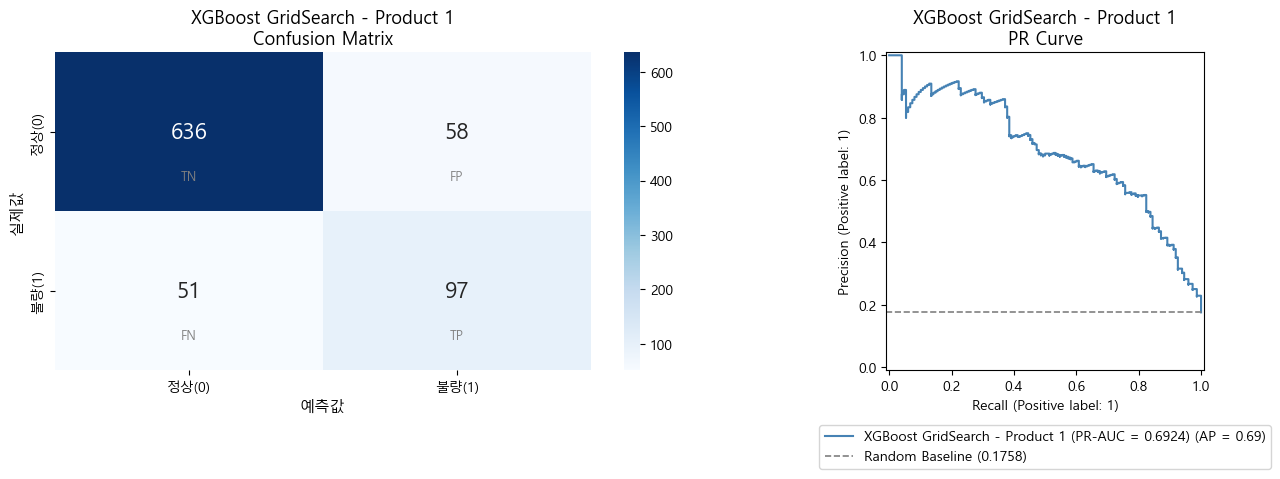

In [32]:
# 5. 성능 평가
evaluate_model(xgb_grid_p1.best_estimator_, X_test_p1, y_test_p1, "XGBoost GridSearch - Product 1")

#### 3.7 LightGBM GridSearch
- 목표:머신러닝 모델의 파라미터 중 최적의 파라미터를 찾아 성능 개선

In [33]:
# 1. 탐색할 파라미터 후보 정의
lgbm_params = {
    "n_estimators"     : [100, 300, 500], 
    "max_depth"        : [3, 5, 7], 
    "learning_rate"    : [0.05, 0.1],
    "subsample"        : [0.8, 1.0], 
    "colsample_bytree" : [0.8, 1.0], 
    "min_child_samples": [10, 20, 30] # XGBoost의 min_child_weight와 유사하지만 샘플 수 단위
}

# 2. 교차검증 설정
cv = StratifiedKFold(
    n_splits=5,       # 5개의 Fold로 분할
    shuffle=True,     # 분할하기 전 데이터 섞기
    random_state=42   # 재현성 보장
)

# 3. GridSearchCV 정의
lgbm_grid_p1 = GridSearchCV(
    estimator=LGBMClassifier(
        class_weight={0: 1, 1: weights},  # 불균형 보정 (정상/불량 = 4.6937)
        random_state=42,
        n_jobs=-1, # 모델 1개 학습 시 병렬 처리
        verbose=-1 # LightGBM 자체 로그 출력x
    ),
    param_grid=lgbm_params, # 탐색할 파라미터 후보
    scoring="average_precision", # 최적화 기준 : PR-AUC
    cv=cv,
    n_jobs=-1,
    verbose=0, 
    refit=True 
)

# 4. 학습
lgbm_grid_p1.fit(X_train_p1, y_train_p1)

print("=" * 40)
print("LightGBM GridSearch 진행 종료")
print(f"최적의 파라미터: {lgbm_grid_p1.best_params_}")
print(f"CV PR-AUC: {lgbm_grid_p1.best_score_:.4f}")
print("=" * 40)

LightGBM GridSearch 진행 종료
최적의 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_samples': 10, 'n_estimators': 500, 'subsample': 0.8}
CV PR-AUC: 0.6016



  LightGBM GridSearch - Product 1

PR-AUC: 0.6717   (Random Baseline: 0.1758)

Classification Report
              precision    recall  f1-score   support

       정상(0)       0.93      0.91      0.92       694
       불량(1)       0.62      0.68      0.65       148

    accuracy                           0.87       842
   macro avg       0.78      0.80      0.79       842
weighted avg       0.88      0.87      0.87       842



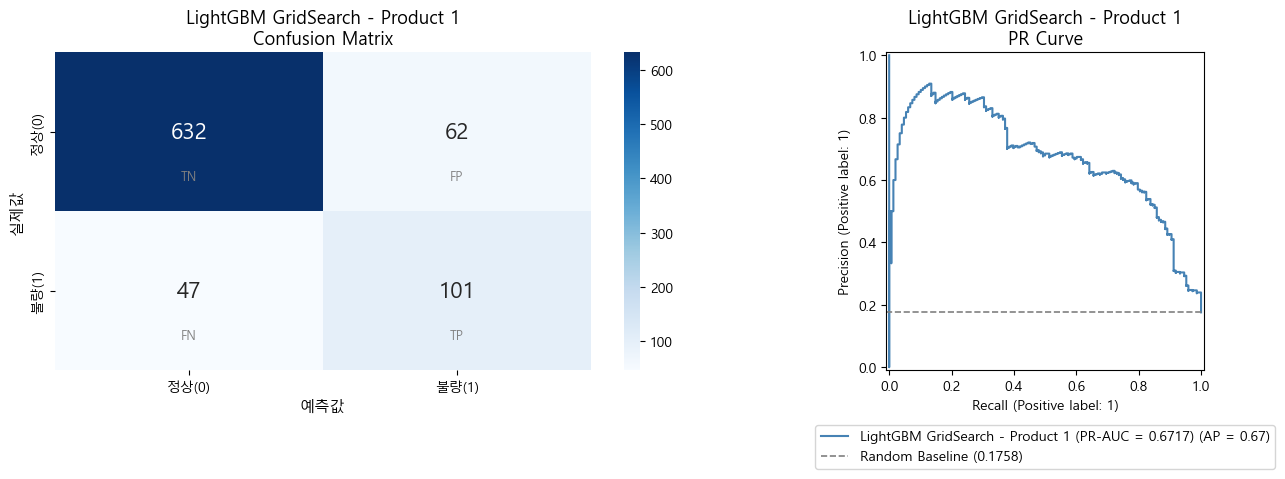

In [35]:
# 5. 성능 평가
evaluate_model(lgbm_grid_p1.best_estimator_, X_test_p1, y_test_p1, "LightGBM GridSearch - Product 1")

### 3.8 SHAP 분석
- 목적 : 모델이 왜 이 샘플을 불량이라 예측했는지 각 피쳐의 기여도를 수치로 확인하기 위해서 수행
- 최종 선정한 모델: GridSearchCV를 통해 최적의 파라미터를 찾아 학습시킨 LightGBM

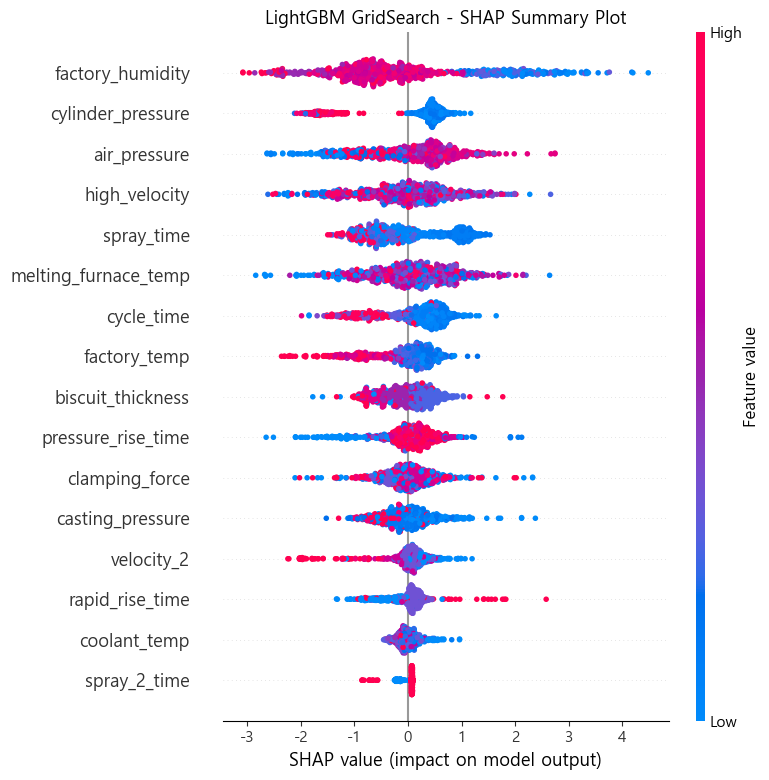

In [ ]:
# 1. SHAP Explainer 생성
# TreeExplainer : XGBoost / LightGBM 같은 트리 기반 모델 전용 SHAP 계산기
explainer = shap.TreeExplainer(lgbm_grid_p1.best_estimator_)

# 2. SHAP 값 계산
# 각 샘플의 각 피쳐가 예측에 얼마나 기여했는지 수치로 계산
shap_values = explainer.shap_values(X_test_p1)

# 3. SHAP Summary Plot
# - 피쳐 값이 높을 때(빨간색) / 낮을 때(파란색) 불량 확률에 어떤 영향을 주는지 표시
# - 오른쪽(+) : 불량 확률 높임 / 왼쪽(-) : 불량 확률 낮춤
# - 위에 있을수록 예측에 영향을 많이 준 피쳐
plt.figure(facecolor='none')
shap.summary_plot(
    shap_values, X_test_p1,
    show=False
)
plt.title("LightGBM GridSearch - SHAP Summary Plot", fontsize=13)
plt.tight_layout()
plt.show()